In [7]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table, Column, vstack, hstack
from astropy.io import ascii
from astropy.coordinates import SkyCoord
import astropy.units as u
from dustmaps.sfd import SFDQuery
from shapely.geometry import Polygon, Point

/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/dustmaps/config.py:151: ConfigWarning: Overriding default configuration file with /scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/share/eups/Linux64/dustmaps_cachedata/gbb0a0c949e+edbf708997/config/.dustmapsrc
  warn('Overriding default configuration file with {}'.format(config_fname),


In [58]:
import os, sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/SALAD/data/')
import kuaizi
kuaizi.set_env(project='SALAD', name='', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)

In [ ]:
# Load stellar streams: https://github.com/cmateu/galstreams
import galstreams
import astropy.coordinates as ac
mws = galstreams.MWStreams(verbose=False, implement_Off=False, print_topcat_friendly_files=False)

In [82]:
mass_size_scatter = 0.25
def mass_size_LVDB(log_m):
    return 0.282 + 0.427 * log_m

def calc_dist_given_angsize(log_m_star, angsize):
    return (10**mass_size_LVDB(log_m_star) / 1000) / (angsize / 206265) / 1000 # Mpc

## Make a sky map for the hosts

In [59]:
obs_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SALAD/LVDB/LVDB_comb_all.csv')

In [60]:
flag = (obs_cat['distance'] * 1e-3 < 5) & (obs_cat['distance_measurement_method'] != 'tf') & (obs_cat['distance_measurement_method'] != 'nam') & (obs_cat['distance_measurement_method'] != 'btf') & (obs_cat['distance_measurement_method'] != 'mem') & (obs_cat['mass_stellar'] > 6.5)

obs_cat = obs_cat[flag]

In [61]:
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=100)

In [62]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from astropy.coordinates import SkyCoord
import astropy.units as u
from dustmaps.sfd import SFDQuery
import skyproj
from matplotlib.colors import ListedColormap, BoundaryNorm

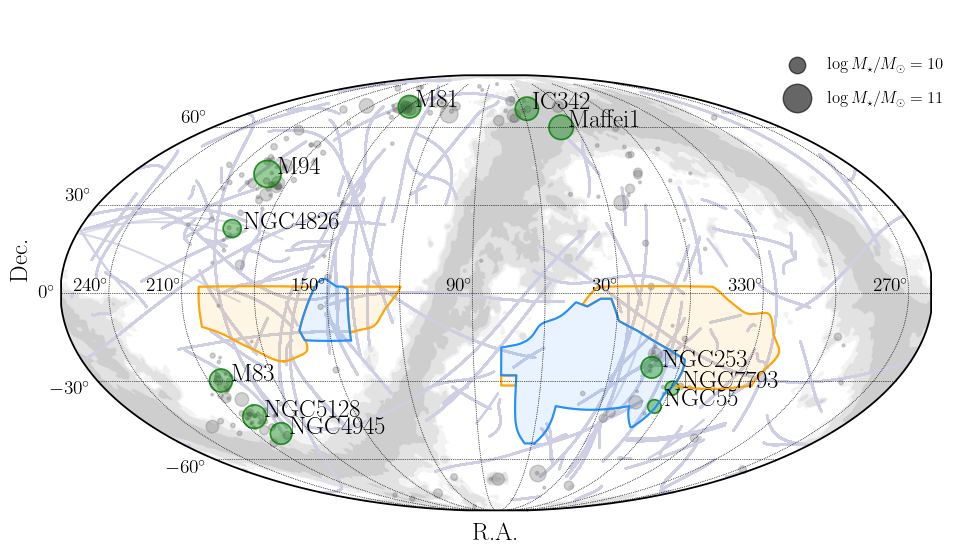

In [87]:
# --- Figure & projection ---
fig, ax = plt.subplots(figsize=(12, 10))
plt.subplots_adjust(top=0.90, right=0.85)

sp = skyproj.MollweideSkyproj(ax=ax, lon_0=80, longitude_ticks='positive', n_grid_lat=6)

filename = '/home/jiaxuanl/Research/Rosesim/data/roman-hlwas-poly-wide.txt'
sp.draw_polygon_file(filename, facecolor='orange', alpha=0.1)
sp.draw_polygon_file(filename, edgecolor='orange')

filename = '/home/jiaxuanl/Research/Rosesim/data/roman-hlwas-poly-medium.txt'
sp.draw_polygon_file(filename, facecolor='dodgerblue', alpha=0.1)
sp.draw_polygon_file(filename, edgecolor='dodgerblue')

# --- Galactic plane (and ±15° bands) ---
# sp.draw_milky_way(width=15)  # thick equator + dashed ±10° by default
show_GP = True
if show_GP:
    # Grid to get EBV
    lon = (np.linspace(0.0, 359.9, 1441)) % 360
    lat = np.linspace(-90.0, 90.0, 721)
    LON, LAT = np.meshgrid(lon, lat)
    eq = SkyCoord(ra=LON*u.deg, dec=LAT*u.deg, frame='icrs')
    
    # Query SFD E(B−V)
    sfd = SFDQuery()
    EBV = sfd(eq)   # same shape as grid
    EBV_clip = np.clip(EBV, 0, np.nanpercentile(EBV, 99))
    EBV_norm = np.ma.masked_invalid(EBV_clip)
    
    from scipy.ndimage import gaussian_filter
    EBV_smooth = gaussian_filter(EBV_norm, sigma=2.0)
    EBV_smooth = np.ma.masked_invalid(EBV_smooth)
    EBV_smooth[EBV_smooth < 0.05] = 0
    
    # Transform to ICRS for plotting on the same projection
    RA = eq.ra.deg
    DEC = eq.dec.deg
    
    levels = np.array([0.15, 0.2, 0.50])
    data = EBV_smooth
    lo, hi = np.nanmin(data), np.nanmax(data)
    boundaries = np.r_[max(lo, levels.min()*0.5), levels, hi]
    N = len(boundaries) - 1
    
    # colors = cm.Blues(np.linspace(0.3, 0.6, N - 1))
    colors = cm.Greys(np.linspace(0.1, 0.3, N - 1))
    colors = np.vstack([[1, 1, 1, 1], colors])
    colors[:, 3] = 0.7
    cmap_disc = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, N, clip=True)

    sp.pcolormesh(
        RA, DEC, EBV_smooth,
        cmap=cmap_disc, norm=norm,
        shading='gouraud', #'auto'
        zorder=-10,
        rasterized=True, edgecolors='none'
    )

sp.ax.set_xlabel('R.A.', fontsize=18)
sp.ax.set_ylabel('Dec.', fontsize=18)
sp.ax.tick_params(labelsize=14, axis='y')
sp.ax.tick_params(labelsize=14, axis='x')
sp.ax.gridlines.set_alpha(0.3)

####################################
############# Hosts ################
####################################

def size_from_logM(logM):
    return 3.0**(logM - 5.5)
    # return 10**(0.3 * 0.5 * (logM + 4))
    # return 10**(0.2 * logM)

hosts = ['NGC 55', 'NGC 7793', 'NGC 253', 'NGC 5128', 'NGC 4945', 'M81', 'M94', 'M83', 'IC 342', 'Maffei 1', 'NGC 4826']
# hosts = ['M101']
sel = np.array([name in hosts for name in obs_cat['name']])

sp.scatter(obs_cat['ra'][~sel], obs_cat['dec'][~sel], c='dimgray', alpha=0.3,
           s=size_from_logM(obs_cat['mass_stellar'][~sel]))

sp.scatter(obs_cat['ra'][sel], obs_cat['dec'][sel], c='green', alpha=0.4,
           s=size_from_logM(obs_cat['mass_stellar'][sel]))
sp.scatter(obs_cat['ra'][sel], obs_cat['dec'][sel], c='none', ec='green', alpha=0.7, lw=1.2,
           s=size_from_logM(obs_cat['mass_stellar'][sel]))

for name in hosts:
    obj = obs_cat[obs_cat['name'] == name][0]
    sp.ax.text(obj['ra'] - 5, obj['dec'], name.replace(' ', ''), fontsize=18)

# sp.ax.set_frame_on(True)
sp.ax.set_ybound(sp.ax.get_ybound()[0], sp.ax.get_ybound()[1] * 1.3)

from matplotlib.lines import Line2D

logM = [10, 11]
sizes = [size_from_logM(m) for m in logM]
handles = [sp.ax.scatter([], [], s=s, c='k', alpha=0.6) for s in sizes]
labels  = [fr'$\log M_\star/M_\odot = {m}$' for m in logM]
sp.ax.legend(handles, labels, fontsize=12,
             loc='upper right', bbox_to_anchor=(1.04, 0.95), labelspacing=1,
             frameon=False)

###############################
#### Stellar streams of MW ####
###############################
show_streams = True
if show_streams:
    # cmap = plt.cm.Greys # plt.cm.Spectral  # or 'tab20', 'plasma', 'turbo', 'Spectral', etc.
    N = len(mws.keys())
    # colors = cmap(np.random.rand(N))  # shape (N, 4), random RGBA
    streams = list(mws.keys())
    for i, st in enumerate(streams[:N]):
        sp.ax.scatter(
            mws[st].track.ra.value, mws[st].track.dec.value,
            marker='.', s=10, alpha=0.5, 
            # fc=colors[i], ec='none',
            fc=plt.cm.Purples(0.3), ec='none',
            label=f"{mws[st].ID:.0f} = {mws[st].stream_name}", zorder=0
        )
        # xo = mws[st].end_points.ra.value[0]
        # yo = mws[st].end_points.dec.value[0]
        # sp.ax.text(
        #     xo, yo,
        #     f"{mws[st].ID}",
        #     ha='center', va='center', fontsize=9,
        # )

plt.savefig('/tigress/jiaxuanl/public_html/figure/Roman_Cycle1/host_sky.png')

shall we do a two-pass?

In [65]:
np.pi * (0.25 * 4)**2 / 0.32, np.pi * (4)**2 / 0.32

(9.817477042468104, 157.07963267948966)

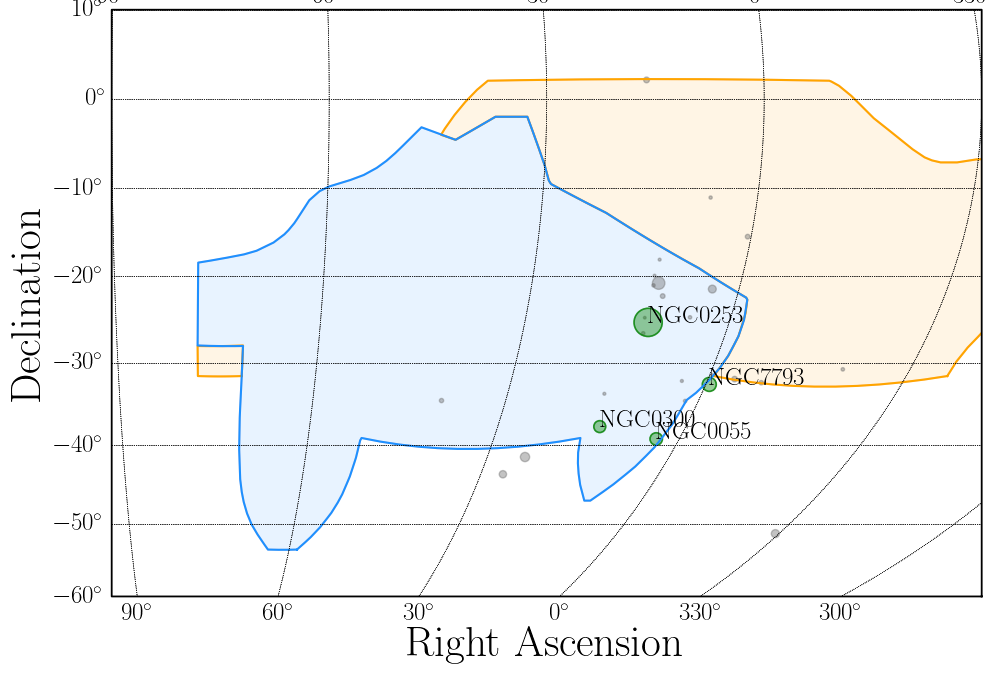

In [208]:
fig, ax = plt.subplots(figsize=(12, 10))
plt.subplots_adjust(top=0.90, right=0.85)

sp = skyproj.MollweideSkyproj(ax=ax, lon_0=80, longitude_ticks='positive', n_grid_lat=6)

filename = '/home/jiaxuanl/Research/Rosesim/data/roman-hlwas-poly-wide.txt'
sp.draw_polygon_file(filename, facecolor='orange', alpha=0.1)
sp.draw_polygon_file(filename, edgecolor='orange')

filename = '/home/jiaxuanl/Research/Rosesim/data/roman-hlwas-poly-medium.txt'
sp.draw_polygon_file(filename, facecolor='dodgerblue', alpha=0.1)
sp.draw_polygon_file(filename, edgecolor='dodgerblue')

sp.set_extent([-30, 90, -60, 10])   # lon range, lat range

hosts = ['NGC0055', 'NGC7793', 'NGC0300', 'NGC0253']
sel = np.array([name in hosts for name in obs_cat['Name']])

sp.scatter(obs_cat['RA'][~sel], obs_cat['Dec'][~sel], c='dimgray', alpha=0.4,
           s=size_from_logM(obs_cat['logKLum'][~sel]))

sp.scatter(obs_cat['RA'][sel], obs_cat['Dec'][sel], c='green', alpha=0.4,
           s=size_from_logM(obs_cat['logKLum'][sel]))
sp.scatter(obs_cat['RA'][sel], obs_cat['Dec'][sel], c='none', ec='green', alpha=0.7, lw=1.2,
           s=size_from_logM(obs_cat['logKLum'][sel]))

for name in hosts:
    obj = obs_cat[obs_cat['Name'] == name]
    sp.ax.text(obj['RA'], obj['Dec'], name, fontsize=18)


## Stellar streams?

In [ ]:
import galstreams
import astropy.coordinates as ac
mws = galstreams.MWStreams(verbose=False, implement_Off=False, print_topcat_friendly_files=False)